# Chiusura del confronto: graduatoria complessiva, trasferimento fuori campione e struttura delle popolazioni

Questo notebook chiude il confronto fra modelli sul dataset NASA C-MAPSS (Turbofan Engine
Degradation Simulation), nel quale la variabile da predire è la vita utile residua di un motore
aeronautico, espressa in cicli di funzionamento e censurata a 125 cicli.

I dati provengono dai file grezzi del NASA Prognostics Data Repository, collocati in `data/raw/` e
non versionati. Il perimetro sperimentale comprende i sottoinsiemi FD001 (un modo di guasto) e
FD003 (due modi di guasto), entrambi a regime operativo unico. Ogni riga della matrice di progetto
è un ciclo di funzionamento di un motore, descritto dal numero di ciclo, dalle impostazioni
operative e dalle letture dei sensori non costanti: 18 variabili su FD001 e 19 su FD003.

## Cosa contiene questo notebook

I cinque notebook precedenti commentano una famiglia di modelli per volta: modelli lineari con
regolarizzazione e selezione delle variabili, superamento della linearità, famiglia ad albero,
metodi a margine e reti. Ciascuno risponde a una domanda interna alla propria famiglia e non può
dire dove quella famiglia si collochi rispetto alle altre.

Questo è il documento in cui i quattro blocchi vengono messi insieme e il confronto diventa una
risposta. Contiene la graduatoria complessiva dei ventidue modelli e delle due baseline sui due
sottoinsiemi, i due esami con cui si stabilisce se il primo posto sia assegnabile, la lettura unica
dell'insieme di verifica ufficiale, il controllo di sensibilità alla soglia di censura e il
raggruppamento non supervisionato delle traiettorie, che descrive le due popolazioni su cui il
confronto è stato replicato.

Il notebook non addestra modelli e non esegue lavoro computazionale: legge gli artefatti già
prodotti dagli script di esperimento e ne ricava figure, tabelle e lettura dei risultati. Si esegue
quindi dall'inizio alla fine in pochi secondi, e i numeri che compaiono qui esistono su disco in
forma tabellare indipendentemente dal notebook. Le quantità derivate dagli artefatti, cioè il
conteggio delle inversioni fra graduatorie, i divari espressi in dispersioni e le tabelle
incrociate dei raggruppamenti, vengono calcolate qui ed esportate in `results/tables/`, dove
diventano artefatto versionato.

Gli artefatti letti sono prodotti da:

    python -m scripts.run_final_ranking
    python -m scripts.run_seed_diagnostic
    python -m scripts.run_holdout
    python -m scripts.run_censoring_sensitivity
    python -m scripts.run_clustering

I primi quattro comandi presuppongono che i quattro blocchi del confronto siano già stati eseguiti
con `python -m scripts.run_linear_models`, `python -m scripts.run_nonlinear_models`,
`python -m scripts.run_tree_models` e `python -m scripts.run_kernel_models`, i cui artefatti non
vengono rigenerati qui.

## Protocollo sotto cui i risultati sono stati prodotti

Il partizionamento avviene per unità motore: tutte le righe di una stessa traiettoria restano dalla
stessa parte della verifica, perché cicli consecutivi dello stesso motore non sono osservazioni
indipendenti. Lo schema è un K-Fold con vincolo di gruppo a 5 fold, ripetuto su tre semi. La
ricerca degli iperparametri opera sulle 5 partizioni di un seme dedicato; la sola configurazione
selezionata viene poi rivalutata sulle 15 partizioni dei tre semi, e sono quei 15 punteggi a
produrre media e dispersione riportate. La metrica di riferimento è la radice dell'errore
quadratico medio, nelle unità del target.

La dispersione riportata è calcolata sui fold e non è l'errore standard della media: i fold
condividono le righe di addestramento. Due modelli il cui divario è inferiore alla dispersione
combinata delle due righe non sono distinguibili sotto questo protocollo e non vengono ordinati.
Questa è la regola di lettura del progetto e vale in ogni sezione che segue.

La colonna del divario in dispersioni misura una distanza e non definisce un ordine: fra righe di
dispersione molto diversa può invertire l'ordinamento dell'errore, che resta quello della colonna
della media.

I punteggi in cross-validation sono ottimisticamente distorti, perché la cross-validation non è
annidata e la ricerca degli iperparametri usa le stesse partizioni su cui la prestazione viene poi
misurata. La distorsione non è uniforme fra le righe: cresce con il numero di configurazioni
valutate, che lungo la graduatoria varia da una a centinaia di migliaia, e la colonna che lo
riporta è parte della tabella esportata.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram
from sklearn.metrics import adjusted_rand_score

# I percorsi sono ricavati dalla posizione del notebook, non dalla directory di lavoro, così che
# l'esecuzione non dipenda da dove viene avviato il kernel.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FINAL_DIR = PROJECT_ROOT / "experiments" / "final"
CLUSTER_DIR = PROJECT_ROOT / "experiments" / "clustering"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

SUBSETS = ("FD001", "FD003")
BASELINES = ("baseline_costante", "baseline_solo_ciclo")

# Le etichette dei blocchi sono quelle che gli artefatti ricevono da `src.final.BLOCKS` e vanno
# riportate alla lettera. Una discordanza produrrebbe punti privi di colore invece di un errore,
# ed è la ragione della verifica in fondo a questa cella.
BLOCK_ORDER = (
    "Modelli lineari",
    "Superamento della linearita'",
    "Famiglia ad albero",
    "Metodi a margine e reti",
    "Baseline",
)
BLOCK_COLOR = dict(zip(BLOCK_ORDER, ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8c8c8c"]))

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})


def load(directory, prefix, name):
    return pd.read_csv(directory / f"{prefix}_{name}.csv")


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight")


def export(frame, name):
    frame.to_csv(TABLES_DIR / f"{name}.csv", index=False)
    return frame


# Le due baseline sono ricalcolate in ogni blocco e negli artefatti portano l'etichetta del blocco
# da cui la graduatoria preleva la copia superstite. Non appartengono a nessuna famiglia di modelli
# e ricevono qui una categoria propria.
def with_baseline_block(frame):
    frame = frame.copy()
    frame.loc[frame["model"].isin(BASELINES), "blocco"] = "Baseline"
    return frame


ranking = {s: with_baseline_block(load(FINAL_DIR, s, "ranking")) for s in SUBSETS}
partition_check = {s: load(FINAL_DIR, s, "partition_check") for s in SUBSETS}
paired = {s: load(FINAL_DIR, s, "paired") for s in SUBSETS}
seed_summary = {s: load(FINAL_DIR, s, "seed_summary") for s in SUBSETS}
seed_diagnostic = {s: load(FINAL_DIR, s, "seed_diagnostic") for s in SUBSETS}
holdout = {s: with_baseline_block(load(FINAL_DIR, s, "holdout")) for s in SUBSETS}
agreement = {s: load(FINAL_DIR, s, "holdout_agreement") for s in SUBSETS}
predictions = {s: load(FINAL_DIR, s, "holdout_predictions") for s in SUBSETS}
censoring = {s: load(FINAL_DIR, s, "censoring_sensitivity") for s in SUBSETS}

# Insiemi su cui il raggruppamento è stato eseguito: i due sottoinsiemi, la loro unione e il
# controllo che ripete l'analisi senza la durata della traiettoria.
CLUSTER_SETS = tuple(SUBSETS) + ("unione",) + tuple(f"{s}_senza_durata" for s in SUBSETS)
cluster_scores = {c: load(CLUSTER_DIR, c, "cluster_scores") for c in CLUSTER_SETS}
cluster_labels = {c: load(CLUSTER_DIR, c, "cluster_labels") for c in CLUSTER_SETS}
kmeans_seeds = {s: load(CLUSTER_DIR, s, "kmeans_seeds") for s in SUBSETS}
linkages = {s: load(CLUSTER_DIR, s, "linkage") for s in SUBSETS}

LABELS = {r["model"]: r["label"] for s in SUBSETS for _, r in ranking[s].iterrows()}

unknown = {b for s in SUBSETS for b in ranking[s]["blocco"].unique()} - set(BLOCK_ORDER)
assert not unknown, f"blocchi presenti negli artefatti e non previsti qui: {unknown}"
print("modelli in graduatoria per sottoinsieme:", {s: len(ranking[s]) for s in SUBSETS})

modelli in graduatoria per sottoinsieme: {'FD001': 24, 'FD003': 24}


## 1. Legittimità della composizione

Comporre in un'unica graduatoria quattro tabelle prodotte da esecuzioni diverse presuppone che i
punteggi siano stati calcolati sugli stessi motori e sulle stesse righe. Il presupposto non è
garantito dal fatto che il codice del protocollo sia unico: basterebbe una versione diversa della
catena dati fra un'esecuzione e l'altra per invalidarlo, e i punteggi resterebbero plausibili.

La verifica è possibile perché le due baseline sono ricalcolate in ogni blocco, quindi ogni blocco
contiene una misura indipendente della stessa quantità sulle stesse partizioni. Il confronto dei
conteggi di righe e di motori di ciascun fold è la firma della partizione, e l'uguaglianza dei
punteggi la corrobora. La verifica precede la graduatoria e la blocca in caso di scostamento,
invece di accompagnarla con una nota.

Questa sezione apre il notebook perché è la condizione di esistenza di tutto ciò che segue.

In [2]:
check = pd.concat([partition_check[s] for s in SUBSETS], ignore_index=True)
export(check, "verifica_partizioni")
print(check.to_string(index=False))
print("\nconteggi di riga e di motore identici su tutte le righe:", bool(check["conteggi_identici"].all()))
print("scarto massimo fra le copie della stessa baseline:", check["scarto_max_rmse"].max())

subset               model            block  n_partizioni  conteggi_identici  scarto_max_rmse
 FD001   baseline_costante    kernel_models            15               True              0.0
 FD001   baseline_costante    linear_models            15               True              0.0
 FD001   baseline_costante nonlinear_models            15               True              0.0
 FD001   baseline_costante      tree_models            15               True              0.0
 FD001 baseline_solo_ciclo    kernel_models            15               True              0.0
 FD001 baseline_solo_ciclo    linear_models            15               True              0.0
 FD001 baseline_solo_ciclo nonlinear_models            15               True              0.0
 FD001 baseline_solo_ciclo      tree_models            15               True              0.0
 FD003   baseline_costante    kernel_models            15               True              0.0
 FD003   baseline_costante    linear_models            15   

Otto confronti per sottoinsieme, due baseline per quattro blocchi. I conteggi coincidono e lo
scarto sui punteggi è nullo: le partizioni dei quattro blocchi sono le stesse e le quattro tabelle
sono componibili. Il valore nullo, e non semplicemente piccolo, è quello atteso, perché le
esecuzioni sono deterministiche e le baseline non hanno iperparametri.

## 2. La graduatoria complessiva

I ventidue modelli del confronto e le due baseline, valutati sulle stesse 15 partizioni sotto lo
stesso protocollo e con lo stesso pre-processing. La tabella riporta per ciascun sottoinsieme
media e dispersione dell'errore e il divario dal primo posto espresso in dispersioni combinate.

I tre metodi di selezione delle variabili compaiono come righe distinte pur avendo selezionato lo
stesso sottoinsieme e ottenuto lo stesso punteggio: fonderli sarebbe una scelta di presentazione
che nasconde il fatto che tre procedure diverse convergono, che è invece un risultato del blocco
lineare.

La figura riporta la media sui 15 fold con la dispersione fra fold. La banda grigia copre le righe
di testa il cui divario dal primo posto resta sotto una dispersione combinata: dentro quella banda
la regola di lettura del progetto non ordina, e la posizione in graduatoria non ha significato. La
banda è orizzontale e copre le righe invece dell'intervallo di errore, perché su questo asse la
scala è fissata dalle due baseline e l'intervallo corrispondente sarebbe una linea di pochi pixel.
Le baseline restano nella figura, come nelle quattro figure di blocco, perché il pavimento
informativo fa parte del risultato.

In [3]:
base = ranking[SUBSETS[0]].set_index("model")[["label", "blocco"]]
pieces = []
for subset in SUBSETS:
    part = ranking[subset].set_index("model")[["rmse_mean", "rmse_std", "divario_in_dispersioni"]].copy()
    # Gli artefatti sono già ordinati sulla metrica di riferimento, quindi la posizione è il rango.
    part.insert(0, "rango", np.arange(1, len(part) + 1))
    pieces.append(part.add_prefix(f"{subset}_"))

complessiva = base.join(pieces).reset_index()
complessiva = complessiva.sort_values(f"{SUBSETS[0]}_rmse_mean").reset_index(drop=True)
complessiva = complessiva[["label", "blocco", "model"]
                          + [f"{s}_{c}" for s in SUBSETS
                             for c in ("rango", "rmse_mean", "rmse_std", "divario_in_dispersioni")]]
export(complessiva, "graduatoria_complessiva")
complessiva.round(3)

,label,blocco,model,FD001_rango,FD001_rmse_mean,FD001_rmse_std,FD001_divario_in_dispersioni,FD003_rango,FD003_rmse_mean,FD003_rmse_std,FD003_divario_in_dispersioni
0,Percettrone multistrato,Metodi a margine e reti,mlp,1,16.581,1.396,0.00,1,14.042,1.057,0.00
1,Foresta casuale,Famiglia ad albero,random_forest,2,16.595,1.462,0.01,5,14.701,1.215,0.58
2,XGBoost,Famiglia ad albero,xgboost,3,16.701,1.361,0.09,2,14.558,1.108,0.48
3,Gradient boosting,Famiglia ad albero,gradient_boosting,4,16.709,1.366,0.09,3,14.578,1.136,0.49
4,Bagging di alberi,Famiglia ad albero,bagging,5,16.894,1.435,0.22,6,14.938,1.105,0.83
5,"SVR, kernel radiale",Metodi a margine e reti,svr_rbf,6,16.961,1.411,0.27,4,14.676,1.366,0.52
6,AdaBoost,Famiglia ad albero,adaboost,7,16.966,1.265,0.29,7,15.521,1.176,1.32
7,Modello additivo generalizzato,Superamento della linearita',gam,8,17.462,1.206,0.68,9,15.946,1.092,1.77
8,Regression spline,Superamento della linearita',spline,9,17.468,1.186,0.69,8,15.914,1.097,1.74
9,Step functions,Superamento della linearita',step_functions,10,17.692,1.204,0.85,10,16.095,1.080,1.92


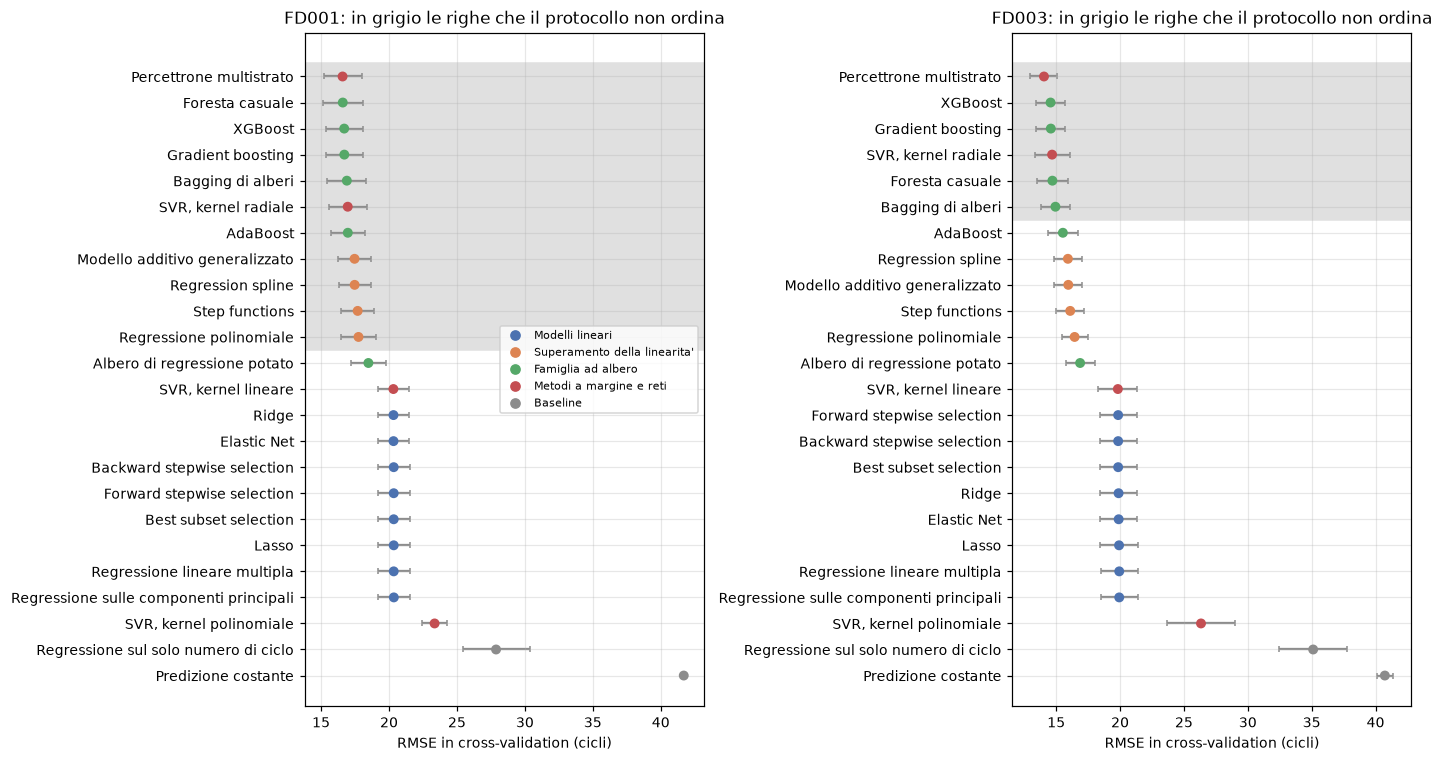

In [4]:
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(13, 7))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    table = ranking[subset]

    # Righe di testa che la regola di lettura non ordina: il tratto contiguo il cui divario dal
    # primo posto resta sotto una dispersione combinata. Si prende il tratto contiguo e non tutte
    # le righe sotto la soglia, perché il divario è una distanza e fra righe di dispersione molto
    # diversa può non seguire l'ordinamento dell'errore.
    separate = table["divario_in_dispersioni"] >= 1.0
    n_testa = int(separate.idxmax()) if separate.any() else len(table)

    reversed_table = table.iloc[::-1].reset_index(drop=True)
    y = np.arange(len(reversed_table))
    # La banda copre le righe e non l'intervallo di errore: su questo asse la scala è fissata dalle
    # due baseline, e l'intervallo corrispondente sarebbe una linea di pochi pixel.
    ax.axhspan(len(reversed_table) - n_testa - 0.5, len(reversed_table) - 0.5,
               color="0.88", zorder=0)
    ax.errorbar(reversed_table["rmse_mean"], y, xerr=reversed_table["rmse_std"],
                fmt="none", ecolor="0.55", capsize=2, zorder=1)
    ax.scatter(reversed_table["rmse_mean"], y, s=30, zorder=2,
               c=reversed_table["blocco"].map(BLOCK_COLOR))
    ax.set_yticks(y)
    ax.set_yticklabels(reversed_table["label"])
    ax.set_xlabel("RMSE in cross-validation (cicli)")
    ax.set_title(f"{subset}: in grigio le righe che il protocollo non ordina")

handles = [plt.Line2D([], [], marker="o", linestyle="", color=BLOCK_COLOR[b], label=b)
           for b in BLOCK_ORDER]
np.atleast_1d(axes)[0].legend(handles=handles, fontsize=7, loc="center right")
save(fig, "graduatoria_complessiva")
plt.show()

In [5]:
colonne = ["subset", "blocco", "label", "config", "rmse_mean", "rmse_std",
           "mae_mean", "r2_mean", "n_configurations", "n_fit"]
dettaglio = pd.concat([ranking[s][colonne] for s in SUBSETS], ignore_index=True)
export(dettaglio, "graduatoria_dettaglio")
print("configurazioni valutate per riga, escursione lungo la graduatoria:")
print(dettaglio.groupby("subset")["n_configurations"].agg(["min", "max"]).to_string())

configurazioni valutate per riga, escursione lungo la graduatoria:
        min     max
subset             
FD001     1  262143
FD003     1  524287


Il percettrone multistrato occupa il primo posto su entrambi i sottoinsiemi, ma la banda grigia
mostra che il primo posto non è una vittoria. La graduatoria individua un gruppo di testa, non un
vincitore, ed è la prima cosa che va detta di questa tabella.

L'ampiezza della banda differisce fra i due sottoinsiemi ed è essa stessa un risultato. Su FD001
scende fino a comprendere i modelli additivi: dal gruppo di testa il protocollo separa soltanto
l'albero singolo, la famiglia lineare e il kernel polinomiale. Su FD003 si ferma dentro il gradino
superiore e i modelli additivi ne restano fuori. Sullo stesso protocollo, con lo stesso numero di
partizioni e lo stesso perimetro di modelli, FD003 consente distinzioni che FD001 non consente,
perché su quel sottoinsieme i divari sono più ampi rispetto alla dispersione fra fold.

La distanza dalle baseline è invece leggibile su ogni riga e di ordine di grandezza superiore alle
distinzioni interne. Il divario rispetto alla baseline sul solo numero di ciclo è quello che misura
ciò che le letture dei sensori aggiungono a un conteggio, ed è molto più ampio su FD003, dove due
modi di guasto producono traiettorie di durata diversa a parità di degrado osservato e il conteggio
da solo predice male.

La tabella di dettaglio riporta il numero di configurazioni valutate per ciascuna riga. Il
protocollo è identico per tutti i modelli, ma le righe non sono a parità di questo fattore: la
distorsione ottimistica cresce con il numero di configurazioni provate sulle stesse partizioni su
cui il punteggio è poi riportato, e passa da una sola valutazione per il bagging alle centinaia di
migliaia della ricerca esaustiva sui sottoinsiemi di variabili. Per quest'ultima l'entità della
distorsione è stata misurata nel blocco lineare con una selezione rifatta dentro ogni fold.

## 3. La struttura per famiglie e la sua replica

La domanda che la tabella precedente non risolve è se la graduatoria descriva i modelli o il
dataset. I due sottoinsiemi sono popolazioni diverse, con lo stesso regime di volo e un numero
diverso di modi di guasto, e il confronto è stato replicato su entrambi sotto un protocollo
letteralmente identico. Se l'ordine si ripete, è una proprietà dei modelli.

La figura mette l'errore su FD001 in ascissa e quello su FD003 in ordinata, un punto per modello,
colorato per famiglia di provenienza. Le due letture sono su popolazioni diverse e i valori non
vanno sottratti fra loro: ciò che si legge è la disposizione dei punti, non la loro distanza dalla
bisettrice, che infatti non è tracciata. Le due baseline sono escluse: il loro errore è di
ordine di grandezza superiore a quello dei modelli e comprimerebbe la scala su cui i modelli
si distinguono. La loro posizione è nella figura della sezione precedente.

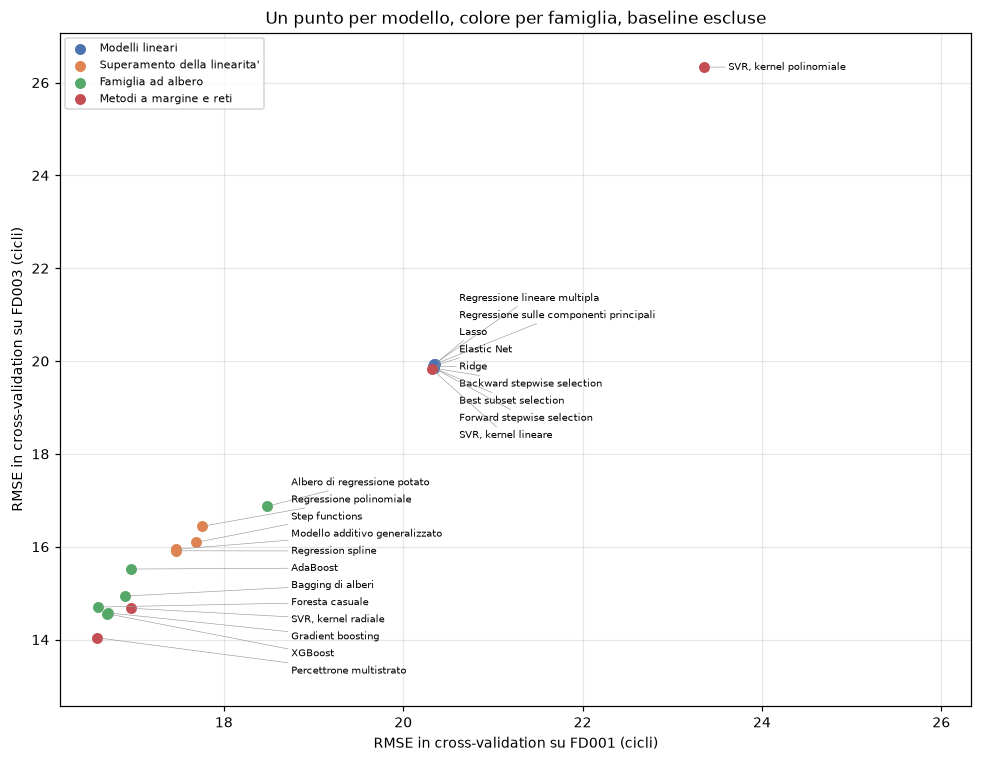

In [6]:
# Le due baseline sono escluse dalla figura: il loro errore comprimerebbe la scala su cui i
# modelli si distinguono, e la loro posizione è già nella figura della sezione precedente.
punti = complessiva[~complessiva["model"].isin(BASELINES)].reset_index(drop=True)
xs = punti[f"{SUBSETS[0]}_rmse_mean"].to_numpy()
ys = punti[f"{SUBSETS[1]}_rmse_mean"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 7))
for blocco in BLOCK_ORDER:
    part = punti[punti["blocco"] == blocco]
    if part.empty:
        continue
    ax.scatter(part[f"{SUBSETS[0]}_rmse_mean"], part[f"{SUBSETS[1]}_rmse_mean"],
               s=38, color=BLOCK_COLOR[blocco], label=blocco, zorder=3)

# I limiti sono fissati prima di collocare le etichette, perché la spaziatura fra etichette è
# espressa in unità dei dati e lo spazio a destra deve bastare a ospitare le colonne di testo.
ampiezza_x = xs.max() - xs.min()
ampiezza_y = ys.max() - ys.min()
ax.set_xlim(xs.min() - 0.06 * ampiezza_x, xs.max() + 0.44 * ampiezza_x)
ax.set_ylim(ys.min() - 0.12 * ampiezza_y, ys.max() + 0.06 * ampiezza_y)

# Molti modelli hanno punteggi quasi coincidenti su entrambi i sottoinsiemi, che è il risultato
# della sezione: annotarli sul punto sovrapporrebbe le etichette. I punti vicini vengono raccolti
# in grumi, le etichette di un grumo incolonnate a destra con una linea sottile che riporta
# ciascuna al proprio punto, e i grumi le cui colonne si sovrapporrebbero vengono fusi.
SOGLIA = 0.15
PASSO = 0.030 * ampiezza_y

grumi = []
for i in np.argsort(xs):
    for grumo in grumi:
        j = grumo[0]
        if np.hypot((xs[i] - xs[j]) / ampiezza_x, (ys[i] - ys[j]) / ampiezza_y) < SOGLIA:
            grumo.append(i)
            break
    else:
        grumi.append([i])


def banda(grumo):
    """Estremi verticali che la colonna di etichette del grumo occuperebbe."""
    centro = float(np.mean([ys[i] for i in grumo]))
    mezza = PASSO * (len(grumo) - 1) / 2
    return centro - mezza, centro + mezza


fuso = True
while fuso:
    fuso = False
    grumi.sort(key=lambda g: banda(g)[0])
    for k in range(len(grumi) - 1):
        if banda(grumi[k])[1] + PASSO / 2 >= banda(grumi[k + 1])[0]:
            grumi[k:k + 2] = [grumi[k] + grumi[k + 1]]
            fuso = True
            break

for grumo in grumi:
    grumo = sorted(grumo, key=lambda i: -ys[i])
    ancora = max(xs[i] for i in grumo) + 0.04 * ampiezza_x
    partenza = banda(grumo)[1]
    for k, i in enumerate(grumo):
        ax.annotate(punti.loc[i, "label"], (xs[i], ys[i]),
                    xytext=(ancora, partenza - k * PASSO), textcoords="data",
                    fontsize=6.5, va="center",
                    arrowprops=dict(arrowstyle="-", linewidth=0.4, color="0.6",
                                    shrinkA=0, shrinkB=3))

ax.set_xlabel(f"RMSE in cross-validation su {SUBSETS[0]} (cicli)")
ax.set_ylabel(f"RMSE in cross-validation su {SUBSETS[1]} (cicli)")
ax.set_title("Un punto per modello, colore per famiglia, baseline escluse")
ax.legend(fontsize=7, loc="upper left")
save(fig, "graduatoria_fra_sottoinsiemi")
plt.show()

In [7]:
rows = []
for subset in SUBSETS:
    for blocco, part in ranking[subset].groupby("blocco"):
        rows.append({
            "sottoinsieme": subset,
            "blocco": blocco,
            "modelli": len(part),
            "rmse_minimo": part["rmse_mean"].min(),
            "rmse_massimo": part["rmse_mean"].max(),
            "ampiezza_interna": part["rmse_mean"].max() - part["rmse_mean"].min(),
            "dispersione_mediana": part["rmse_std"].median(),
        })
gradini = pd.DataFrame(rows).sort_values(["sottoinsieme", "rmse_minimo"]).reset_index(drop=True)
export(gradini, "gradini_per_famiglia")

modelli = complessiva[~complessiva["model"].isin(BASELINES)]
concordanza = modelli[f"{SUBSETS[0]}_rmse_mean"].corr(modelli[f"{SUBSETS[1]}_rmse_mean"],
                                                      method="spearman")
print(f"correlazione di rango fra i due sottoinsiemi, sui soli modelli: {concordanza:.3f}\n")
gradini.round(3)

correlazione di rango fra i due sottoinsiemi, sui soli modelli: 0.972



,sottoinsieme,blocco,modelli,rmse_minimo,rmse_massimo,ampiezza_interna,dispersione_mediana
0,FD001,Metodi a margine e reti,4,16.581,23.354,6.774,1.255
1,FD001,Famiglia ad albero,6,16.595,18.480,1.885,1.364
2,FD001,Superamento della linearita',4,17.462,17.752,0.289,1.205
3,FD001,Modelli lineari,8,20.327,20.353,0.026,1.182
4,FD001,Baseline,2,27.878,41.694,13.815,1.301
5,FD003,Metodi a margine e reti,4,14.042,26.335,12.293,1.442
6,FD003,Famiglia ad albero,6,14.558,16.871,2.313,1.131
7,FD003,Superamento della linearita',4,15.914,16.439,0.525,1.086
8,FD003,Modelli lineari,8,19.849,19.934,0.086,1.451
9,FD003,Baseline,2,35.116,40.730,5.613,1.648


I punti si dispongono in gruppi che coincidono con le famiglie, e i gruppi si susseguono nello
stesso ordine lungo entrambi gli assi. La struttura è a tre gradini: i modelli lineari, ai quali si
affianca la macchina a vettori di supporto con kernel lineare, che stima la stessa classe di
funzioni sotto una perdita diversa; i modelli non lineari additivi, con l'albero singolo al loro
margine; gli insiemi di alberi, il kernel radiale e la rete in cima.

I gradini non sono però ugualmente separati, e la distinzione va fatta. Il divario fra la famiglia
lineare e quella additiva è ampio su entrambi i sottoinsiemi e supera largamente la dispersione fra
fold. Quello fra la famiglia additiva e il gradino di testa è molto più stretto: resta leggibile su
FD003 e non lo è su FD001, ed è la ragione per cui la banda della sezione precedente ha ampiezza
diversa nei due pannelli.

La correlazione di rango fra i due sottoinsiemi resta alta, quindi l'ordine dei gradini si replica su
due popolazioni diverse. Ciò che cambia da un sottoinsieme all'altro non è l'ordine ma la risoluzione
con cui il protocollo lo distingue. Il risultato del confronto è quindi la scala delle famiglie e non
l'ordinamento dentro il gruppo di testa, che il protocollo dichiara di non poter leggere.

Dentro il blocco lineare tutte le righe, dalla regressione senza penalizzazione alla ricerca
esaustiva su centinaia di migliaia di sottoinsiemi, cadono in una frazione di ciclo. Su questa
matrice la penalizzazione e la selezione delle variabili non hanno varianza da recuperare, e il
limite è la classe di funzioni. Il gradino successivo, che introduce una funzione liscia per
variabile, è il primo divario del progetto che superi la soglia di leggibilità.

Il kernel polinomiale è l'unico punto fuori dalla struttura, peggiore del kernel lineare su
entrambi i sottoinsiemi. La sua riga è un limite superiore delle prestazioni della tecnica e non una
sua misura, perché la griglia dell'ampiezza è chiusa dal lato in cui il profilo scende ancora, per
una ragione di condizionamento numerico documentata nel quarto blocco.

## 4. Il vertice, primo esame: confronto appaiato fold per fold

Le due sezioni che seguono rispondono alla stessa domanda con due misure indipendenti: se il primo
posto sia una proprietà del modello o dell'estrazione.

Le 15 partizioni sono le stesse per tutti i modelli e per tutti i blocchi, quindi la differenza fra
due modelli si può calcolare fold per fold invece che confrontando due medie con le rispettive
dispersioni. La difficoltà del fold, che è la componente dominante della dispersione riportata in
graduatoria, è comune ai due modelli e si elide nella differenza. La media delle differenze coincide
per costruzione con la differenza delle medie: l'informazione aggiuntiva sta nella dispersione della
differenza e nella concordanza del segno.

La lettura è fuori dal materiale del corso ed è dichiarata tale. Resta descrittiva: non viene
prodotta alcuna statistica test, e il rapporto fra media e dispersione della differenza non è
convertibile in un livello di significatività, perché i 15 fold condividono le righe di
addestramento e non sono osservazioni indipendenti. La regola di lettura fissata dal protocollo
resta quella principale e questa non la sostituisce.

Un valore positivo indica che il modello sbaglia più del riferimento. L'annotazione accanto a ogni
punto conta su quanti fold il segno si conferma.

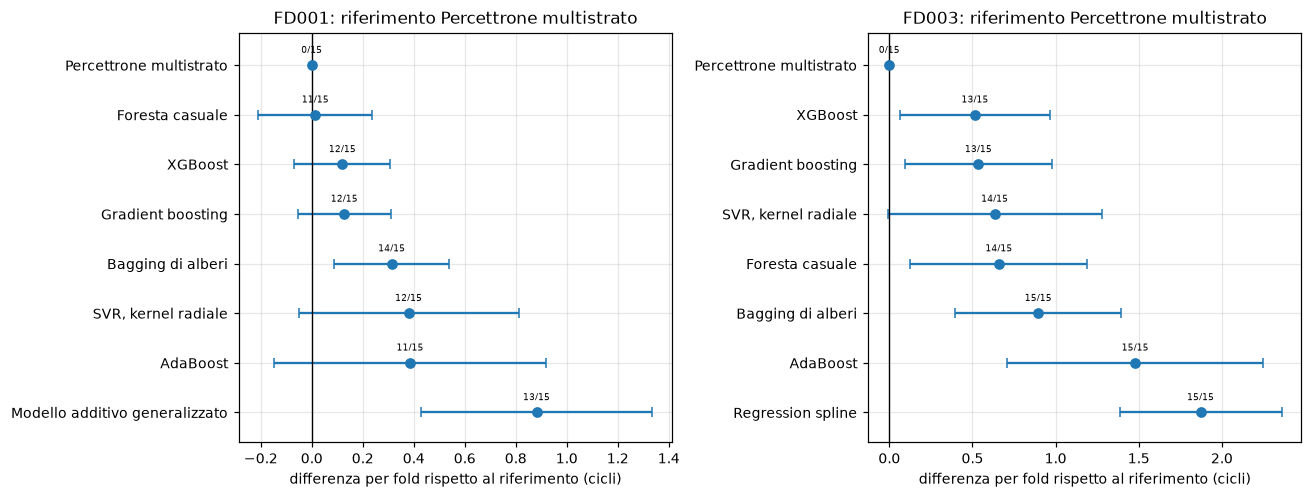

In [8]:
VERTICE = 8  # righe mostrate in figura, per leggibilità: la tabella esportata le contiene tutte

frames = []
for subset in SUBSETS:
    part = paired[subset].copy()
    part.insert(0, "sottoinsieme", subset)
    part.insert(1, "modello", part["model"].map(LABELS))
    part["riferimento"] = part["riferimento"].map(LABELS)
    frames.append(part)
appaiato = pd.concat(frames, ignore_index=True)
export(appaiato.drop(columns=["model"]), "confronto_appaiato")

fig, axes = plt.subplots(1, len(SUBSETS), figsize=(12, 4.6))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    part = paired[subset]
    part = part[~part["model"].isin(BASELINES)].sort_values("rmse_mean").head(VERTICE)
    part = part.iloc[::-1].reset_index(drop=True)
    y = np.arange(len(part))
    ax.errorbar(part["differenza_media"], y, xerr=part["differenza_std"], fmt="o", capsize=3)
    ax.axvline(0.0, color="black", linewidth=0.9)
    for i, row in part.iterrows():
        ax.annotate(f"{int(row['fold_peggiori'])}/{int(row['n_fold'])}",
                    (row["differenza_media"], i), fontsize=6,
                    xytext=(0, 8), textcoords="offset points", ha="center")
    ax.set_yticks(y)
    ax.set_yticklabels(part["model"].map(LABELS))
    # Margine verticale esplicito: l'annotazione è collocata in punti sopra il marcatore e non
    # entra nel calcolo automatico dei limiti, quindi la riga più alta verrebbe tagliata.
    ax.set_ylim(-0.6, len(part) - 0.35)
    ax.set_xlabel("differenza per fold rispetto al riferimento (cicli)")
    ax.set_title(f"{subset}: riferimento {LABELS[paired[subset]['riferimento'].iloc[0]]}")
save(fig, "vertice_confronto_appaiato")
plt.show()

In [9]:
colonne = ["sottoinsieme", "modello", "rmse_mean", "rmse_std", "differenza_media",
           "differenza_std", "differenza_in_dispersioni", "fold_peggiori", "n_fold"]
vertice = appaiato[~appaiato["model"].isin(BASELINES)].sort_values(["sottoinsieme", "rmse_mean"])
vertice.groupby("sottoinsieme").head(VERTICE)[colonne].round(3)

,sottoinsieme,modello,rmse_mean,rmse_std,differenza_media,differenza_std,differenza_in_dispersioni,fold_peggiori,n_fold
0,FD001,Percettrone multistrato,16.581,1.396,0.000,0.000,NaN,0,15
1,FD001,Foresta casuale,16.595,1.462,0.014,0.223,0.064,11,15
2,FD001,XGBoost,16.701,1.361,0.120,0.188,0.640,12,15
3,FD001,Gradient boosting,16.709,1.366,0.128,0.183,0.698,12,15
4,FD001,Bagging di alberi,16.894,1.435,0.314,0.225,1.395,14,15
5,FD001,"SVR, kernel radiale",16.961,1.411,0.380,0.432,0.880,12,15
6,FD001,AdaBoost,16.966,1.265,0.386,0.533,0.724,11,15
7,FD001,Modello additivo generalizzato,17.462,1.206,0.882,0.454,1.943,13,15
24,FD003,Percettrone multistrato,14.042,1.057,0.000,0.000,NaN,0,15
25,FD003,XGBoost,14.558,1.108,0.515,0.451,1.142,13,15


La dispersione della differenza è molto minore di quella dei singoli punteggi, il che conferma che i
modelli del vertice sbagliano sugli stessi fold: la variabilità riportata in graduatoria è in gran
parte difficoltà della partizione e non incertezza sul confronto.

I due sottoinsiemi danno esiti diversi. Su FD001 il modello che segue il riferimento ha differenza
media di una frazione di centesimo di dispersione e segno che non si conferma nemmeno sulla
maggioranza dei fold: il primo posto è un pareggio pieno, e il segno della media è determinato da
pochi fold. Su FD003 la differenza dal secondo è più ampia, la dispersione della differenza è meno
della metà di quella dei punteggi e il segno si conferma sulla grande maggioranza dei fold. La
formulazione corretta è che il divario resta sotto la soglia di leggibilità fissata dal protocollo
ma non è distribuito a caso fra i fold. Le due affermazioni convivono e vanno riportate entrambe.

L'annotazione con il conteggio dei fold è la parte più informativa della figura, perché è l'unica
che non dipende da quanto una media si sposta.

## 5. Il vertice, secondo esame: il seme dello stimatore

Il primo posto è occupato su entrambi i sottoinsiemi da un modello con una componente casuale
interna, e i modelli che lo seguono entro la soglia di leggibilità sono anch'essi stocastici. Il
protocollo fissa un solo seme di stimatore per modello, uguale per tutti, quindi la dispersione
riportata in graduatoria è quella fra le 15 partizioni e non contiene la variabilità dovuta al seme.

La configurazione selezionata dei tre modelli in testa è stata rivalutata sulle stesse 15 partizioni
con cinque semi. Il primo seme è quello del protocollo e serve da controllo di fedeltà della
ricostruzione. Il risultato è diagnostico e non entra in graduatoria: cambiare la regola sui semi
per i soli modelli stocastici romperebbe la parità del protocollo, che è il fondamento del confronto.

Nella figura ogni punto grigio è la media sulle 15 partizioni ottenuta con un seme. Il cerchio vuoto
segna il seme del protocollo, cioè il valore che compare in graduatoria, e la barra verticale la
media fra i cinque semi. Il cerchio è vuoto perché dove i semi sono quasi coincidenti un marcatore
pieno coprirebbe i punti che deve segnalare, e una riga a dispersione nulla diventerebbe
indistinguibile da un dato mancante.

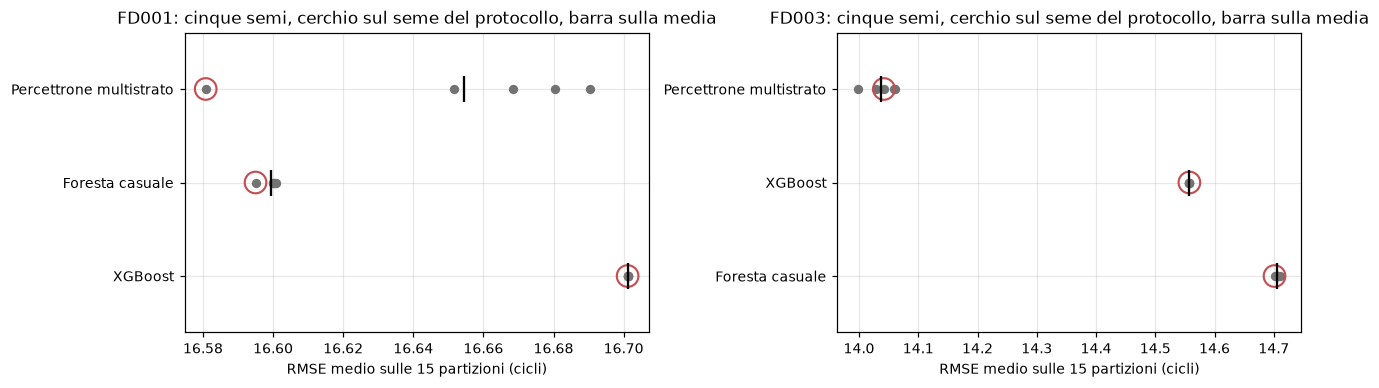

In [10]:
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(12, 3.6))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    block = seed_diagnostic[subset]
    presenti = set(block["model"])
    ordine = [m for m in ranking[subset]["model"] if m in presenti][::-1]
    for i, model in enumerate(ordine):
        part = block[block["model"] == model]
        ax.scatter(part["rmse_mean"], np.full(len(part), i), s=26, color="0.45", zorder=2)
        # Cerchio vuoto e non marcatore pieno: dove i cinque semi sono quasi coincidenti un
        # marcatore pieno coprirebbe i punti che deve segnalare, e una riga con dispersione nulla
        # diventerebbe indistinguibile da un dato mancante.
        protocollo = part[part["estimator_seed"] == part["estimator_seed"].min()]
        ax.scatter(protocollo["rmse_mean"], [i], marker="o", s=200, facecolors="none",
                   edgecolors="#c44e52", linewidths=1.4, zorder=3)
        ax.scatter([part["rmse_mean"].mean()], [i], marker="|", s=280, color="black", zorder=4)
    ax.set_yticks(np.arange(len(ordine)))
    ax.set_yticklabels([LABELS[m] for m in ordine])
    ax.set_ylim(-0.6, len(ordine) - 0.4)
    ax.set_xlabel("RMSE medio sulle 15 partizioni (cicli)")
    ax.set_title(f"{subset}: cinque semi, cerchio sul seme del protocollo, barra sulla media")
save(fig, "variabilita_seme_stimatore")
plt.show()

In [11]:
frames = []
for subset in SUBSETS:
    part = seed_summary[subset].copy()
    posizione = ranking[subset].set_index("model")["rmse_mean"]
    part["rmse_seme_del_protocollo"] = part["model"].map(posizione)
    # Divario che separa i primi due della graduatoria: è la quantità con cui la dispersione fra
    # semi va confrontata, perché è ciò che l'ordinamento del vertice deve poter distinguere.
    primi = ranking[subset][~ranking[subset]["model"].isin(BASELINES)]["rmse_mean"].to_numpy()[:2]
    part["divario_fra_i_primi_due"] = primi[1] - primi[0]
    frames.append(part)

semi = pd.concat(frames, ignore_index=True)
semi = semi[["subset", "label", "rmse_seme_del_protocollo", "rmse_medio_fra_semi",
             "dispersione_fra_semi", "rmse_minimo", "rmse_massimo", "escursione", "n_semi",
             "divario_fra_i_primi_due"]]
export(semi, "variabilita_seme_stimatore")
semi.round(4)

,subset,label,rmse_seme_del_protocollo,rmse_medio_fra_semi,dispersione_fra_semi,rmse_minimo,rmse_massimo,escursione,n_semi,divario_fra_i_primi_due
0,FD001,Foresta casuale,16.5950,16.5993,0.0024,16.5950,16.6007,0.0057,5,0.0142
1,FD001,Percettrone multistrato,16.5808,16.6544,0.0436,16.5808,16.6905,0.1097,5,0.0142
2,FD001,XGBoost,16.7011,16.7011,0.0000,16.7011,16.7011,0.0000,5,0.0142
3,FD003,Percettrone multistrato,14.0421,14.0378,0.0256,13.9988,14.0607,0.0619,5,0.5154
4,FD003,XGBoost,14.5575,14.5575,0.0000,14.5575,14.5575,0.0000,5,0.5154
5,FD003,Foresta casuale,14.7012,14.7060,0.0035,14.7012,14.7108,0.0096,5,0.5154


I due sottoinsiemi danno esiti opposti, ed è il motivo per cui questa misura esiste.

Su FD001 la dispersione fra semi della rete è di alcune volte superiore al divario che la separa dal
secondo in graduatoria, il seme del protocollo è quello che produce il valore migliore dei cinque, e
sulla media fra semi l'ordine dei primi due si inverte. La graduatoria non è viziata, perché il seme
è fissato per tutti i modelli e non è stato scelto guardando i risultati, ma la conclusione
difendibile è che su FD001 il primo posto sia un effetto dell'estrazione.

Su FD003 il divario dal secondo è di un ordine di grandezza superiore alla dispersione fra semi e il
seme del protocollo produce un valore intermedio fra i cinque. Il divario resta sotto la soglia di
leggibilità fissata dal protocollo, che si misura sulla dispersione fra fold, ma non è attribuibile
all'inizializzazione.

Due righe della tabella vanno lette con cautela opposta. La foresta casuale ha dispersione fra semi
di uno o due ordini di grandezza inferiore a quella della rete: la media su trecento alberi assorbe
la variabilità del campionamento delle righe e delle colonne, mentre la rete ha una sola stima e la
sua inizializzazione entra per intero nel risultato. XGBoost ha dispersione esattamente nulla, e non
è stabilità: la configurazione del registro lascia il campionamento di righe e colonne ai valori
predefiniti, quindi non esiste sorgente di casualità e il seme è inerte. Quella riga misura
l'assenza di variabilità da misurare, ed è un limite del diagnostico e non un suo risultato.

Le due letture del vertice concordano: su FD001 il primo posto non è assegnabile, su FD003 regge.

## 6. Il trasferimento fuori campione

I file di verifica ufficiali del dataset non entrano in nessuna scelta del progetto, né di variabili
né di iperparametri né di ordinamento. I ventidue modelli selezionati e le due baseline sono stati
riaddestrati sull'intera parte di addestramento di ciascun sottoinsieme e valutati una sola volta,
secondo una regola di lettura fissata prima che esistesse il codice che quell'insieme lo legge.

La regola è che l'insieme di verifica misura il trasferimento fuori campione e non riordina la
graduatoria: ha un solo punteggio per modello, senza misura di variabilità, e ordinare su di esso
significherebbe ordinare su un numero di cui non si conosce l'incertezza. La graduatoria del
progetto resta quella in cross-validation.

Le traiettorie di verifica sono troncate in un punto casuale prima del guasto e ogni unità ha una
sola etichetta, riferita all'ultimo ciclo osservato. Da quella si ricava il target a ogni ciclo, e le
letture prodotte sono tre: su tutti i cicli, sul solo ultimo ciclo di ciascuna unità, e sull'ultimo
ciclo contro il target non censurato. Le tre riguardano popolazioni di cicli diverse, e nessuna di
esse è confrontabile con l'errore in cross-validation: i loro valori non si sottraggono fra loro.

La figura riporta due delle tre letture sullo stesso asse verticale per compattezza, distinguendole
con il marcatore. Anche in questo caso i due valori di uno stesso modello non vanno confrontati fra
loro: ciò che si legge è la relazione fra l'errore in cross-validation e quello sulla verifica,
separatamente per ciascuna lettura. Le baseline sono escluse dalla figura per la ragione già vista,
e restano nella tabella esportata.

In [12]:
colonne = ["subset", "blocco", "label", "rmse_cv_mean", "rmse_cv_std",
           "rmse_all_cycles", "r2_all_cycles", "rmse_last_cycle", "r2_last_cycle",
           "rmse_last_cycle_raw", "rango_cv", "rango_verifica_tutti", "rango_verifica_ultimo"]
verifica = pd.concat([holdout[s][colonne] for s in SUBSETS], ignore_index=True)
export(verifica, "verifica_ufficiale")
verifica.round(3)

,subset,blocco,label,rmse_cv_mean,rmse_cv_std,rmse_all_cycles,r2_all_cycles,rmse_last_cycle,r2_last_cycle,rmse_last_cycle_raw,rango_cv,rango_verifica_tutti,rango_verifica_ultimo
0,FD001,Metodi a margine e reti,Percettrone multistrato,16.581,1.396,15.518,0.683,16.723,0.826,17.975,1,1,3
1,FD001,Famiglia ad albero,Foresta casuale,16.595,1.462,15.644,0.678,16.806,0.824,18.020,2,2,4
2,FD001,Famiglia ad albero,XGBoost,16.701,1.361,15.657,0.678,16.577,0.829,17.819,3,4,2
3,FD001,Famiglia ad albero,Gradient boosting,16.709,1.366,15.655,0.678,16.515,0.830,17.766,4,3,1
4,FD001,Famiglia ad albero,Bagging di alberi,16.894,1.435,15.868,0.669,16.949,0.821,18.129,5,6,5
5,FD001,Metodi a margine e reti,"SVR, kernel radiale",16.961,1.411,15.712,0.675,17.119,0.818,18.253,6,5,6
6,FD001,Famiglia ad albero,AdaBoost,16.966,1.265,16.550,0.640,17.184,0.816,18.585,7,9,8
7,FD001,Superamento della linearita',Modello additivo generalizzato,17.462,1.206,16.406,0.646,17.152,0.817,18.331,8,7,7
8,FD001,Superamento della linearita',Regression spline,17.468,1.186,16.506,0.642,17.507,0.809,18.639,9,8,10
9,FD001,Superamento della linearita',Step functions,17.692,1.204,16.564,0.639,17.229,0.815,18.375,10,10,9


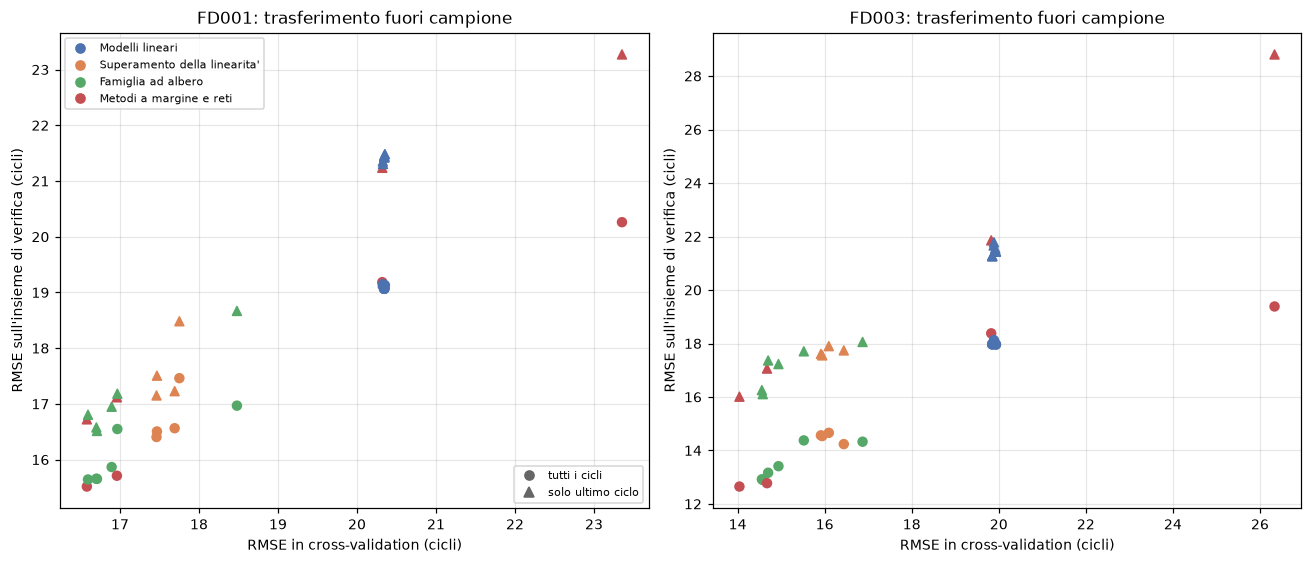

In [13]:
LETTURE = {"rmse_all_cycles": "tutti i cicli", "rmse_last_cycle": "solo ultimo ciclo"}
MARCATORI = ("o", "^")

fig, axes = plt.subplots(1, len(SUBSETS), figsize=(12, 5.2))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    # Le baseline sono escluse per la stessa ragione della figura fra sottoinsiemi: il loro errore
    # comprimerebbe la nuvola dei modelli in un angolo. Restano nella tabella esportata.
    table = holdout[subset]
    table = table[~table["model"].isin(BASELINES)]
    for colonna, marker in zip(LETTURE, MARCATORI):
        ax.scatter(table["rmse_cv_mean"], table[colonna], marker=marker, s=34,
                   c=table["blocco"].map(BLOCK_COLOR), zorder=2)
    ax.set_xlabel("RMSE in cross-validation (cicli)")
    ax.set_ylabel("RMSE sull'insieme di verifica (cicli)")
    ax.set_title(f"{subset}: trasferimento fuori campione")

blocchi = [b for b in BLOCK_ORDER
           if b != "Baseline" and (holdout[SUBSETS[0]]["blocco"] == b).any()]
colori = [plt.Line2D([], [], marker="o", linestyle="", color=BLOCK_COLOR[b], label=b)
          for b in blocchi]
marcatori = [plt.Line2D([], [], marker=m, linestyle="", color="0.4", label=LETTURE[c])
             for c, m in zip(LETTURE, MARCATORI)]
prima = np.atleast_1d(axes)[0]
prima.add_artist(prima.legend(handles=colori, fontsize=7, loc="upper left"))
prima.legend(handles=marcatori, fontsize=7, loc="lower right")
save(fig, "trasferimento_verifica")
plt.show()

In [14]:
def coppie_separabili(table, lettura):
    """Inversioni fra le sole coppie che la regola di lettura del progetto separa.

    La correlazione di rango, presa da sola, è fuorviante: impone un ordine anche fra righe che il
    protocollo dichiara non ordinabili, e un riordinamento interno a un gruppo indistinguibile la
    abbassa senza che nulla si sia davvero invertito. Il conteggio riguarda quindi le sole coppie il
    cui divario in cross-validation supera la dispersione combinata delle due righe.
    """
    modelli = table[~table["model"].isin(BASELINES)].reset_index(drop=True)
    cv = modelli["rmse_cv_mean"].to_numpy()
    std = modelli["rmse_cv_std"].to_numpy()
    fuori = modelli[lettura].to_numpy()

    separabili = invertite = 0
    for i in range(len(modelli)):
        for j in range(i + 1, len(modelli)):
            scala = np.sqrt((std[i] ** 2 + std[j] ** 2) / 2.0)
            if abs(cv[i] - cv[j]) <= scala:
                continue
            separabili += 1
            invertite += int(np.sign(cv[i] - cv[j]) != np.sign(fuori[i] - fuori[j]))
    return separabili, invertite, len(modelli)


LETTURE_COMPLETE = dict(LETTURE, rmse_last_cycle_raw="ultimo ciclo, target non censurato")

rows = []
for subset in SUBSETS:
    table = holdout[subset]
    modelli = table[~table["model"].isin(BASELINES)]
    for colonna, nome in LETTURE_COMPLETE.items():
        separabili, invertite, n = coppie_separabili(table, colonna)
        rows.append({
            "sottoinsieme": subset,
            "lettura": nome,
            "modelli": n,
            "coppie_totali": n * (n - 1) // 2,
            "coppie_separabili": separabili,
            "inversioni": invertite,
            "correlazione_di_rango": modelli["rmse_cv_mean"].corr(modelli[colonna], method="spearman"),
        })

concordanza = pd.DataFrame(rows)
export(concordanza, "concordanza_graduatorie")

print("correlazione di rango registrata dagli artefatti dell'esperimento:")
print(pd.concat([agreement[s] for s in SUBSETS], ignore_index=True).to_string(index=False))
print()
concordanza.round(3)

correlazione di rango registrata dagli artefatti dell'esperimento:
subset                            lettura  spearman_con_cv  n_modelli
 FD001                      tutti i cicli         0.888324         22
 FD001                  solo ultimo ciclo         0.984450         22
 FD001 ultimo ciclo, target non censurato         0.981058         22
 FD003                      tutti i cicli         0.868607         22
 FD003                  solo ultimo ciclo         0.930128         22
 FD003 ultimo ciclo, target non censurato         0.913817         22



,sottoinsieme,lettura,modelli,coppie_totali,coppie_separabili,inversioni,correlazione_di_rango
0,FD001,tutti i cicli,22,231,136,0,0.888
1,FD001,solo ultimo ciclo,22,231,136,0,0.984
2,FD001,"ultimo ciclo, target non censurato",22,231,136,0,0.981
3,FD003,tutti i cicli,22,231,158,1,0.869
4,FD003,solo ultimo ciclo,22,231,158,0,0.930
5,FD003,"ultimo ciclo, target non censurato",22,231,158,1,0.914


L'errore sulla verifica è più basso di quello in cross-validation su ogni riga della tabella. Non è
un trasferimento migliore del previsto: è la composizione della popolazione. Le traiettorie di
verifica sono troncate in un punto casuale e contengono in proporzione molte più righe della fase
iniziale di vita, dove il target è appiattito sulla soglia di censura, quindi la variabilità da
predire è minore e l'errore assoluto cala per costruzione. Il coefficiente di determinazione, che
rapporta l'errore alla variabilità disponibile, si muove infatti nella direzione opposta e scende.

Il risultato della sezione è il conteggio delle inversioni. La correlazione di rango è alta ma
inferiore all'unità su tutte le letture, e presa da sola suggerirebbe un trasferimento imperfetto.
Ristretta alle sole coppie che il protocollo separa, la discordanza quasi scompare: le poche
inversioni residue valgono centesimi di ciclo e riguardano righe che la regola di lettura tratta
come indistinguibili. L'ordine che il protocollo dichiara leggibile si trasferisce quindi
integralmente su una popolazione indipendente, e la correlazione inferiore all'unità è prodotta da
riordinamenti interni a gruppi già dichiarati non ordinabili.

Sul vertice, il trasferimento conferma quanto già mostrato dal seme dello stimatore. Su FD001 il
primo posto cambia titolare a seconda della lettura, con quattro modelli in tre decimi di ciclo: due
misure indipendenti, la variabilità fra semi e il trasferimento fuori campione, portano alla stessa
conclusione. Su FD003 la rete resta prima in tutte le letture, come lo era in cross-validation e come
il diagnostico sul seme aveva mostrato non attribuibile all'inizializzazione. Ciò che regge senza
riserve è la struttura per famiglie: i tre gradini si ripetono identici sui due sottoinsiemi e in
tutte le letture.

Il conteggio delle inversioni è una lettura fuori dal materiale del corso ed è descrittiva: non
produce alcuna statistica test.

Va inoltre dichiarato che l'insieme di verifica non è rimasto del tutto intatto fino a questo punto.
In fase di convalida del protocollo è stato letto per le due baseline e per la regressione lineare
multipla, cioè modelli senza iperparametri, e quella lettura non ha condizionato alcuna scelta. La
riproduzione di quei punteggi è servita qui da controllo di fedeltà della catena dati.

## 7. Dove si concentra l'errore

La metrica di riferimento è un numero solo e non dice in quale fase della vita di un motore
l'errore si produca. La distinzione conta su questo dataset, perché la censura del target crea due
regimi con profili di errore diversi: una fase iniziale in cui il target è costante alla soglia e il
degrado non è osservabile dai sensori, e una fase finale in cui la vita residua decresce e il degrado
si legge.

Le predizioni su ogni riga dell'insieme di verifica sono un artefatto della lettura precedente, e
permettono di scomporre l'errore per fascia di vita residua vera senza alcun calcolo aggiuntivo sui
modelli. La figura riporta il miglior modello di ciascuna famiglia e la baseline sul solo numero di
ciclo, che è il termine rispetto a cui il guadagno dei modelli va letto. I modelli sono scelti una
volta sola, sulla graduatoria del primo sottoinsieme, e gli stessi compaiono in entrambi i pannelli:
sceglierli per sottoinsieme renderebbe i due pannelli non confrontabili. Dentro una famiglia il
rappresentante conta poco, perché le righe distano fra loro meno dei divari fra famiglie.

Le righe con vita residua pari alla soglia sono raccolte in una fascia a parte: sono quelle in cui il
target è censurato e la predizione corretta è un valore costante.

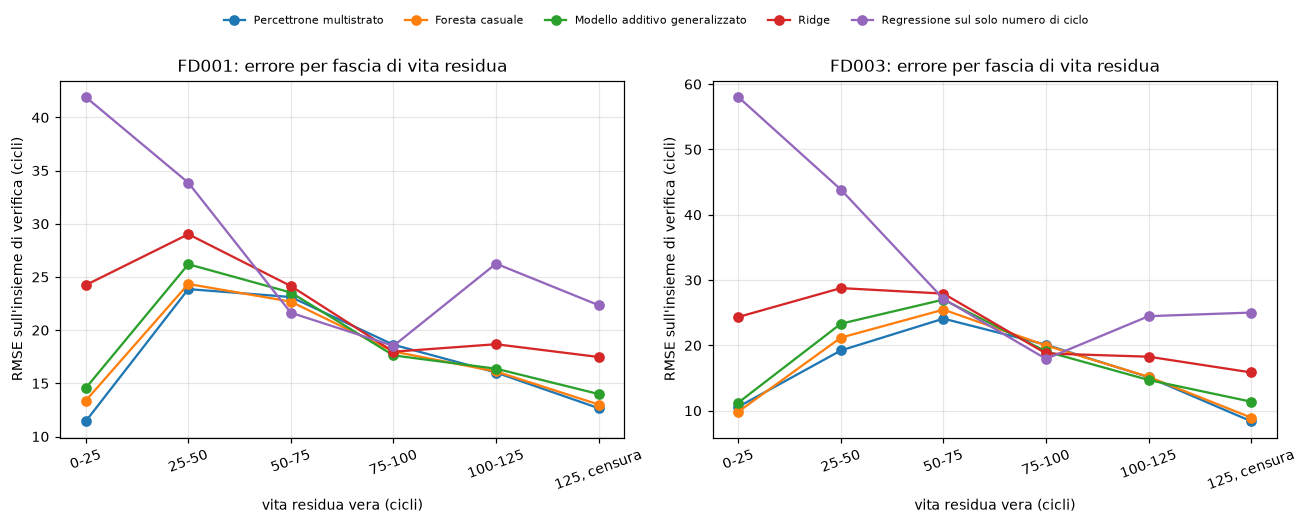

In [15]:
FASCE = [0, 25, 50, 75, 100, 125]
NOMI_FASCE = ["0-25", "25-50", "50-75", "75-100", "100-125"]
ORDINE_FASCE = NOMI_FASCE + ["125, censura"]

# Un modello per famiglia, il meglio piazzato nella graduatoria del primo sottoinsieme, più la
# baseline sul solo numero di ciclo. La scelta è fatta una volta sola e vale per entrambi i
# pannelli: sceglierla per sottoinsieme produrrebbe due pannelli con modelli diversi, non
# confrontabili fra loro e con lo stesso colore assegnato a modelli diversi. Dentro una famiglia
# il rappresentante conta poco, perché le righe distano fra loro meno dei divari fra famiglie.
riferimento = ranking[SUBSETS[0]]
riferimento = riferimento[~riferimento["model"].isin(BASELINES)]
SCELTI = list(riferimento.groupby("blocco", sort=False).head(1)["model"]) + ["baseline_solo_ciclo"]

frames = []
for subset in SUBSETS:
    part = predictions[subset]
    part = part[part["model"].isin(SCELTI)].copy()
    part["errore"] = part["y_pred"] - part["y_true"]
    # Le righe al valore di soglia sono quelle censurate. Una riga con vita residua esattamente
    # pari alla soglia e non censurata sarebbe indistinguibile, e cade nella stessa fascia.
    censurate = part["y_true"] >= part["y_true"].max()
    part["fascia"] = pd.cut(part["y_true"], bins=FASCE, right=False, labels=NOMI_FASCE).astype(object)
    part.loc[censurate, "fascia"] = "125, censura"

    profilo = (part.groupby(["model", "fascia"])["errore"]
               .agg(rmse=lambda e: float(np.sqrt(np.mean(np.square(e)))),
                    errore_medio="mean", righe="size")
               .reset_index())
    profilo.insert(0, "sottoinsieme", subset)
    profilo.insert(2, "modello", profilo["model"].map(LABELS))
    frames.append(profilo)

profili = pd.concat(frames, ignore_index=True)
export(profili.drop(columns=["model"]), "errore_per_vita_residua")

fig, axes = plt.subplots(1, len(SUBSETS), figsize=(12, 4.4))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    part = profili[profili["sottoinsieme"] == subset]
    # L'iterazione segue l'ordine di SCELTI e non quello dei dati, così che lo stesso modello
    # riceva lo stesso colore nei due pannelli.
    for model in SCELTI:
        block = part[part["model"] == model].set_index("fascia").reindex(ORDINE_FASCE)
        ax.plot(ORDINE_FASCE, block["rmse"], marker="o", label=LABELS[model])
    ax.tick_params(axis="x", labelrotation=20)
    ax.set_xlabel("vita residua vera (cicli)")
    ax.set_ylabel("RMSE sull'insieme di verifica (cicli)")
    ax.set_title(f"{subset}: errore per fascia di vita residua")

# Legenda unica sopra i due pannelli: i modelli sono gli stessi a destra e a sinistra, e una
# legenda per pannello si sovrapporrebbe alle curve in entrambi.
linee, etichette = np.atleast_1d(axes)[0].get_legend_handles_labels()
fig.legend(linee, etichette, loc="upper center", ncol=len(SCELTI), fontsize=7,
           bbox_to_anchor=(0.5, 1.08), frameon=False)
save(fig, "errore_per_vita_residua")
plt.show()

Il profilo non è monotono e ha la stessa forma su tutti i modelli e su entrambi i sottoinsiemi:
l'errore è minimo ai due estremi dell'asse e ha un massimo nella fascia intermedia. I tre tratti
hanno cause diverse e vanno letti separatamente.

Nella fascia censurata il target è costante per costruzione, quindi al modello basta produrre il
valore di soglia, e l'errore vi risulta inferiore alla media del modello. Quella fascia contiene la
maggior parte delle righe di verifica, quindi la metrica complessiva è pesata verso la parte più
facile del problema: è una cautela sul numero di testa e non un merito dei modelli. Va inoltre letta
come effetto della censura e non come prova che la prima parte della vita sia predicibile. Senza
censura quella è la regione in cui letture quasi identiche corrispondono a vite residue diverse, ed è
la componente di errore che il controllo sulla soglia vede riemergere come esplosione della
dispersione fra fold.

Vicino al guasto l'errore torna basso, perché il degrado è ampio e si legge nelle letture dei
sensori. È la fascia in cui una previsione di vita residua serve a decidere, ed è quella in cui i
modelli si comportano meglio.

Il massimo sta nella transizione, dove il modello deve stabilire con quale velocità la vita residua
stia scendendo, cioè collocare l'inizio del degrado. È la parte effettivamente difficile del
problema, e la metrica complessiva la diluisce fra le altre.

La baseline sul solo numero di ciclo ha il profilo opposto: il suo errore è massimo proprio nella
fascia più vicina al guasto, perché una funzione monotona del conteggio non distingue un motore che
si guasta presto da uno che si guasta tardi. La distanza fra i modelli e quella baseline è quindi
massima dove il conteggio fallisce e si riduce nelle fasce intermedie. È un'affermazione più precisa
del divario complessivo riportato in graduatoria: l'informazione che le letture dei sensori
aggiungono non è distribuita lungo la vita del motore, è concentrata dove il conteggio non basta.

I gradini si leggono anche per fascia. Il rappresentante della famiglia lineare sta sopra quelli del
gradino di testa in quasi tutte le fasce e su entrambi i sottoinsiemi, quindi la struttura che la
graduatoria mostra sull'aggregato non è prodotta da una sola parte della vita del motore.

I due pannelli non condividono la scala verticale e le altezze non vanno confrontate fra
sottoinsiemi. La tabella esportata riporta, oltre all'errore quadratico, l'errore medio con segno,
che dice in quale direzione ciascun modello sbaglia in ciascuna fascia.

La scomposizione è descrittiva e non entra in graduatoria: le fasce sono definite sul target vero,
quindi non sono note al momento della predizione e non definiscono una metrica utilizzabile per
selezionare un modello.

## 8. La soglia di censura

La censura del target a 125 cicli è un'ipotesi di modellazione fissata a priori, e i valori assoluti
di tutte le metriche dipendono da essa. Il controllo misura se ne dipenda anche l'ordine fra le
famiglie di modelli.

Un modello per famiglia, quello meglio piazzato su FD001, è stato rivalutato sulle stesse 15
partizioni con la censura disattivata, insieme alle due baseline. Le configurazioni restano quelle
selezionate sotto censura e la ricerca non viene rifatta: rifarla equivarrebbe a condurre un secondo
confronto completo su una diversa definizione del target. Ne consegue un limite che rende la lettura
a senso unico, e va dichiarato: ogni configurazione è stata scelta per un target di scala diversa da
quello su cui viene qui valutata, quindi una famiglia il cui ottimo si sposti molto risulta
svantaggiata. Se l'ordine regge nonostante questo il risultato è solido; se si invertisse, non se ne
potrebbe concludere che la famiglia è peggiore sotto target non censurato.

I due regimi hanno scale del target diverse e i loro errori non sono confrontabili in valore
assoluto. La sola quantità trasferibile è l'ordine dentro ciascun regime, ed è la ragione per cui la
figura riporta il divario dal migliore espresso in dispersioni e non l'errore. La linea orizzontale è
la soglia di leggibilità: sotto di essa il protocollo non separa. La figura riporta i quattro
modelli; il divario delle baseline vale decine di dispersioni e fisserebbe la scala, rendendo
invisibile proprio la soglia, quindi le loro righe restano nella sola tabella esportata.

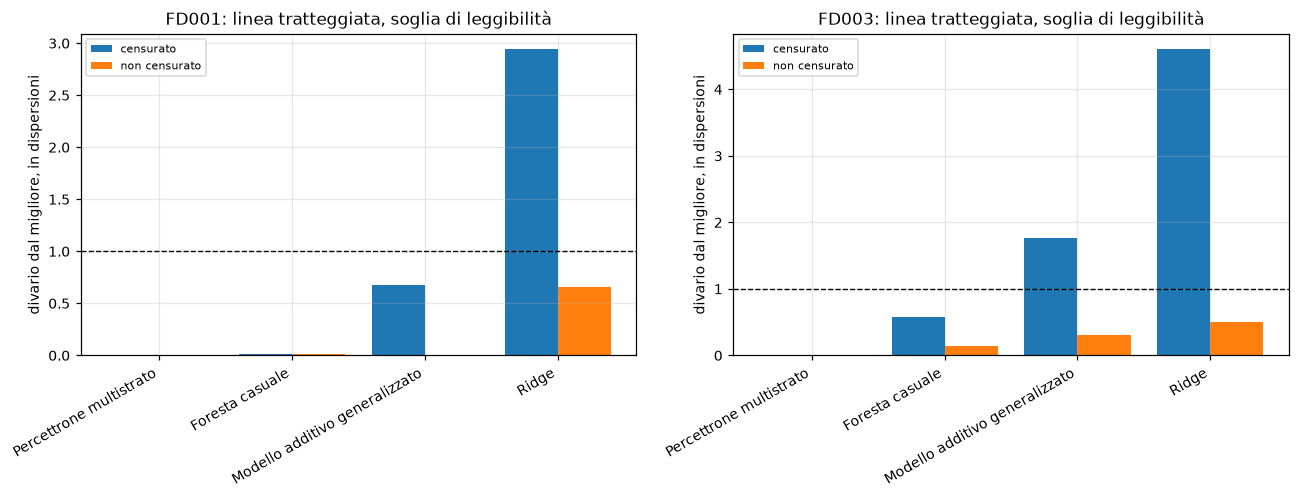

,subset,regime,label,rmse_mean,rmse_std,rango_nel_regime,divario_in_dispersioni
0,FD001,censurato,Percettrone multistrato,16.581,1.396,1,0.000
1,FD001,censurato,Foresta casuale,16.595,1.462,2,0.010
2,FD001,censurato,Modello additivo generalizzato,17.462,1.206,3,0.676
3,FD001,censurato,Ridge,20.327,1.137,4,2.943
4,FD001,censurato,Regressione sul solo numero di ciclo,27.878,2.467,5,5.637
5,FD001,censurato,Predizione costante,41.694,0.135,6,25.331
6,FD001,non censurato,Percettrone multistrato,37.138,5.681,1,0.000
7,FD001,non censurato,Modello additivo generalizzato,37.182,5.844,2,0.008
8,FD001,non censurato,Foresta casuale,37.204,6.209,3,0.011
9,FD001,non censurato,Ridge,40.797,5.520,4,0.653


In [16]:
frames = []
for subset in SUBSETS:
    part = censoring[subset].copy()
    for regime, block in part.groupby("regime"):
        migliore = block["rmse_mean"].min()
        dispersione_migliore = block.loc[block["rmse_mean"].idxmin(), "rmse_std"]
        scala = np.sqrt((block["rmse_std"] ** 2 + dispersione_migliore ** 2) / 2.0)
        part.loc[block.index, "divario_in_dispersioni"] = (block["rmse_mean"] - migliore) / scala
    frames.append(part)

sensibilita = pd.concat(frames, ignore_index=True)
colonne = ["subset", "regime", "label", "rmse_mean", "rmse_std", "rango_nel_regime",
           "divario_in_dispersioni"]
export(sensibilita[colonne], "sensibilita_censura")

REGIMI = list(dict.fromkeys(sensibilita["regime"]))
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(12, 4.6))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    # Solo i modelli: il divario delle baseline vale decine di dispersioni e fisserebbe la scala,
    # rendendo invisibile la soglia di leggibilità, che è ciò che la figura deve mostrare. Le
    # baseline restano nella tabella esportata.
    part = sensibilita[(sensibilita["subset"] == subset)
                       & (~sensibilita["model"].isin(BASELINES))]
    ordine = part[part["regime"] == REGIMI[0]].sort_values("rmse_mean")["label"].tolist()
    x = np.arange(len(ordine))
    larghezza = 0.8 / len(REGIMI)
    for k, regime in enumerate(REGIMI):
        valori = part[part["regime"] == regime].set_index("label").loc[ordine, "divario_in_dispersioni"]
        ax.bar(x + (k - (len(REGIMI) - 1) / 2) * larghezza, valori, larghezza, label=regime)
    ax.axhline(1.0, color="black", linestyle="--", linewidth=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(ordine, rotation=30, ha="right")
    ax.set_ylabel("divario dal migliore, in dispersioni")
    ax.set_title(f"{subset}: linea tratteggiata, soglia di leggibilità")
    ax.legend(fontsize=7)
save(fig, "sensibilita_censura")
plt.show()

sensibilita[colonne].round(3)

L'ordine regge. Su FD003 le quattro righe si dispongono nello stesso ordine nei due regimi. Su FD001
due righe si scambiano, ma nel regime censurato distano meno della loro dispersione combinata, cioè
sono già due righe che il protocollo non ordina: lo scambio non inverte un ordine leggibile. La
famiglia lineare resta ultima fra i modelli in entrambi i regimi e su entrambi i sottoinsiemi, quindi
la separazione fra il primo gradino e gli altri non dipende dalla soglia.

Il risultato più informativo non riguarda però l'ordine ma la risoluzione. Togliendo la censura la
dispersione fra fold cresce di un fattore quattro su FD001 e di quasi dieci su FD003, mentre il
divario fra la famiglia lineare e la testa resta quasi invariato in cicli. Misurato nell'unità del
protocollo, cioè in dispersioni, quel divario crolla: nel regime non censurato la regola di lettura
non separa più nessuna coppia fra i modelli esaminati, compresa quella che divide la famiglia lineare
dalle altre. Le due baseline restano invece separate dai modelli in entrambi i regimi: ciò che la
censura rende leggibile è la distinzione fra famiglie, non quella fra un modello e un pavimento
informativo.

La censura non sposta quindi i modelli: cambia la risoluzione con cui il confronto li distingue. È un
argomento a favore della soglia indipendente da quello con cui era stata fissata, e non è circolare,
perché abbassare la soglia riduce l'errore per costruzione ma nulla nella costruzione impone che
aumenti anche il rapporto fra i divari e la dispersione fra fold.

Il controllo riguarda quattro modelli su ventidue e una sola soglia alternativa, che è l'assenza di
soglia: non dice nulla sul comportamento a soglie intermedie.

## 9. Le due popolazioni su cui il confronto è stato replicato

Ogni sezione precedente ha incontrato la stessa asimmetria: FD003 ha traiettorie più lunghe,
dispersione delle durate quasi doppia, punteggi migliori, e chiede alla rete una capacità maggiore.
Questa sezione stabilisce che cosa distingua le due popolazioni, guardandole senza il target.

I metodi non supervisionati non sono modelli in confronto: il task del progetto è di regressione, e
il raggruppamento entra come strumento di commento. L'unità di osservazione è il motore e non il
ciclo, perché la domanda riguarda la forma della traiettoria nel suo complesso, e sono usate le sole
traiettorie di addestramento, perché quelle di verifica sono troncate e la loro durata osservata non
è la durata del motore. Ogni motore è descritto dalla lettura media di fine vita e dalla deriva
totale di ciascun sensore, più la durata della traiettoria.

Il modo di guasto dei singoli motori non è distribuito con il dataset. Dentro un sottoinsieme non
esiste quindi un riferimento contro cui misurare la correttezza di un raggruppamento, e l'indice di
Rand corretto è usato come accordo fra due raggruppamenti diversi. Il numero di gruppi si legge sulla
silhouette.

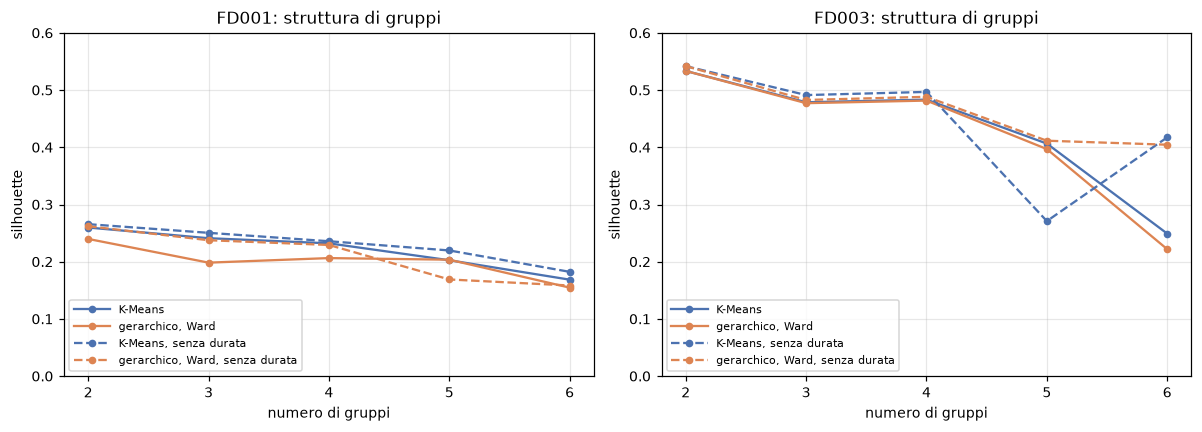

In [17]:
# Colore per algoritmo e stile della linea per variante: il controllo senza la durata non è un
# quinto e sesto metodo, è lo stesso metodo su una matrice diversa.
COLORE_METODO = {"kmeans": "#4c72b0", "agglomerative": "#dd8452"}

fig, axes = plt.subplots(1, len(SUBSETS), figsize=(11, 4))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    for nome, stile, suffisso in ((subset, "-", ""),
                                  (f"{subset}_senza_durata", "--", ", senza durata")):
        scores = cluster_scores[nome].fillna({"linkage": ""})
        for metodo, etichetta in (("kmeans", "K-Means"), ("agglomerative", "gerarchico, Ward")):
            part = scores[(scores["metodo"] == metodo)
                          & (scores["linkage"].isin(["", "ward"]))].sort_values("n_clusters")
            if part.empty:
                continue
            # Marcatore piccolo e segmento di legenda lungo: con il marcatore predefinito il
            # campione della legenda è quasi tutto coperto e il tratteggio non si distingue.
            ax.plot(part["n_clusters"], part["silhouette"], stile, marker="o", markersize=4,
                    color=COLORE_METODO[metodo], label=f"{etichetta}{suffisso}")
    ax.set_ylim(0.0, 0.6)
    ax.set_xticks(sorted(cluster_scores[subset]["n_clusters"].unique()))
    ax.set_xlabel("numero di gruppi")
    ax.set_ylabel("silhouette")
    ax.set_title(f"{subset}: struttura di gruppi")
    ax.legend(fontsize=7, loc="lower left", handlelength=3.4)
save(fig, "silhouette_raggruppamento")
plt.show()

In [18]:
punteggi = pd.concat([cluster_scores[c] for c in CLUSTER_SETS], ignore_index=True)
export(punteggi, "raggruppamento_punteggi")
punteggi[punteggi["n_clusters"] == 2].round(3).to_string(index=False)

'           insieme  n_clusters        metodo  linkage  silhouette  ari_vs_kmeans  dimensione_minima  dimensione_massima  ari_vs_reference\n             FD001           2        kmeans      NaN       0.260          1.000                 36                  64               NaN\n             FD001           2 agglomerative     ward       0.240          0.702                 42                  58               NaN\n             FD001           2 agglomerative complete       0.201          0.031                 50                  50               NaN\n             FD001           2 agglomerative  average       0.163         -0.024                  3                  97               NaN\n             FD003           2        kmeans      NaN       0.533          1.000                 44                  56               NaN\n             FD003           2 agglomerative     ward       0.533          1.000                 44                  56               NaN\n             FD003        

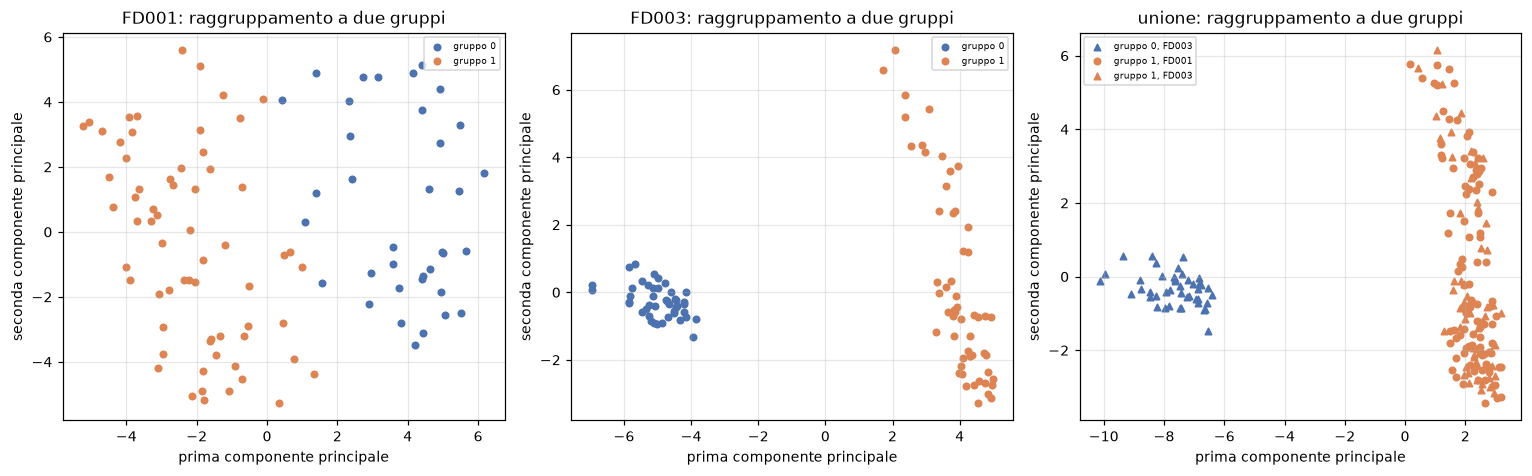

In [19]:
# Colore per gruppo e marcatore per provenienza. Codificare la provenienza con il colore
# spezzerebbe in due lo stesso gruppo dell'unione, che è proprio ciò che la figura deve mostrare
# unito.
COLORE_GRUPPO = ("#4c72b0", "#dd8452", "#55a868", "#c44e52")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, nome in zip(axes, (SUBSETS[0], SUBSETS[1], "unione")):
    etichette = cluster_labels[nome]
    if "sottoinsieme" in etichette.columns:
        for (gruppo, origine), part in etichette.groupby(["kmeans_k2", "sottoinsieme"]):
            ax.scatter(part["pc1"], part["pc2"], s=18,
                       color=COLORE_GRUPPO[int(gruppo) % len(COLORE_GRUPPO)],
                       marker="o" if origine == SUBSETS[0] else "^",
                       label=f"gruppo {int(gruppo)}, {origine}")
    else:
        for gruppo, part in etichette.groupby("kmeans_k2"):
            ax.scatter(part["pc1"], part["pc2"], s=18,
                       color=COLORE_GRUPPO[int(gruppo) % len(COLORE_GRUPPO)],
                       label=f"gruppo {int(gruppo)}")
    ax.set_xlabel("prima componente principale")
    ax.set_ylabel("seconda componente principale")
    ax.set_title(f"{nome}: raggruppamento a due gruppi")
    ax.legend(fontsize=6)
save(fig, "raggruppamento_traiettorie")
plt.show()

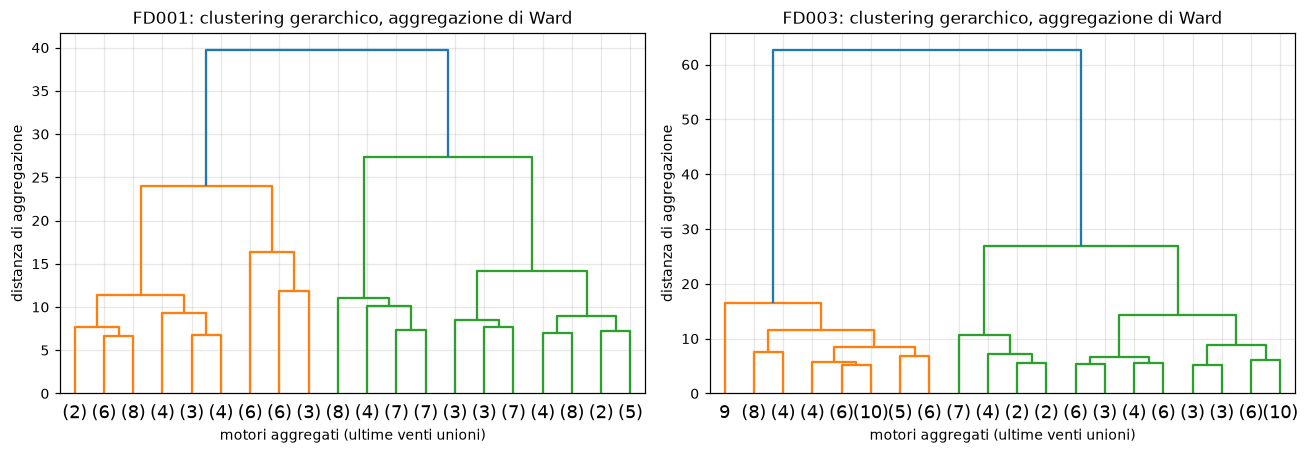

In [20]:
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(12, 4.2))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    dendrogram(linkages[subset].to_numpy(dtype=float), truncate_mode="lastp", p=20, ax=ax)
    ax.set_xlabel("motori aggregati (ultime venti unioni)")
    ax.set_ylabel("distanza di aggregazione")
    ax.set_title(f"{subset}: clustering gerarchico, aggregazione di Ward")
save(fig, "dendrogrammi_traiettorie")
plt.show()

In [21]:
rows = []
for subset in SUBSETS:
    etichette = cluster_labels[subset]
    rows.append({"insieme": subset, "gruppo": "tutti", "motori": len(etichette),
                 "durata_media": etichette["durata"].mean(),
                 "dispersione_durata": etichette["durata"].std(ddof=1)})
    for gruppo, part in etichette.groupby("kmeans_k2"):
        rows.append({"insieme": subset, "gruppo": str(int(gruppo)), "motori": len(part),
                     "durata_media": part["durata"].mean(),
                     "dispersione_durata": part["durata"].std(ddof=1)})

unione = cluster_labels["unione"]
for gruppo, part in unione.groupby("kmeans_k2"):
    riga = {"insieme": "unione", "gruppo": str(int(gruppo)), "motori": len(part),
            "durata_media": part["durata"].mean(),
            "dispersione_durata": part["durata"].std(ddof=1)}
    for subset in SUBSETS:
        riga[f"motori_da_{subset}"] = int((part["sottoinsieme"] == subset).sum())
    rows.append(riga)

popolazioni = pd.DataFrame(rows)
export(popolazioni, "raggruppamento_popolazioni")

print("unione: gruppo per sottoinsieme di provenienza")
print(pd.crosstab(unione["kmeans_k2"], unione["sottoinsieme"]).to_string())
print()
popolazioni.round(2)

unione: gruppo per sottoinsieme di provenienza
sottoinsieme  FD001  FD003
kmeans_k2                 
0                 0     44
1               100     56



,insieme,gruppo,motori,durata_media,dispersione_durata,motori_da_FD001,motori_da_FD003
0,FD001,tutti,100,206.31,46.34,NaN,NaN
1,FD001,0,36,211.89,37.35,NaN,NaN
2,FD001,1,64,203.17,50.72,NaN,NaN
3,FD003,tutti,100,247.20,86.48,NaN,NaN
4,FD003,0,44,304.66,94.33,NaN,NaN
5,FD003,1,56,202.05,42.31,NaN,NaN
6,unione,0,44,304.66,94.33,0.0,44.0
7,unione,1,156,204.78,44.84,100.0,56.0


In [22]:
controlli = []
for subset in SUBSETS:
    completa = cluster_labels[subset].set_index("unit")["kmeans_k2"]
    variante = cluster_labels[f"{subset}_senza_durata"].set_index("unit")["kmeans_k2"]
    controlli.append({
        "controllo": "accordo fra la partizione completa e quella senza la durata",
        "insieme": subset,
        "valore": adjusted_rand_score(completa.loc[variante.index], variante),
    })
    semi = kmeans_seeds[subset].query("n_clusters == 2")
    controlli.append({
        "controllo": "accordo minimo fra i cinque semi di K-Means",
        "insieme": subset,
        "valore": float(semi["ari_vs_seme_riferimento"].min()),
    })
    scores = cluster_scores[subset].query("n_clusters == 2 and metodo == 'agglomerative' and linkage == 'ward'")
    controlli.append({
        "controllo": "accordo fra K-Means e clustering gerarchico di Ward",
        "insieme": subset,
        "valore": float(scores["ari_vs_kmeans"].iloc[0]),
    })

unione_kmeans = cluster_scores["unione"].query("n_clusters == 2 and metodo == 'kmeans'")
controlli.append({
    "controllo": "accordo fra la partizione dell'unione e il sottoinsieme di provenienza",
    "insieme": "unione",
    "valore": float(unione_kmeans["ari_vs_reference"].iloc[0]),
})

controlli = pd.DataFrame(controlli)
export(controlli, "raggruppamento_controlli")
controlli.round(3)

,controllo,insieme,valore
0,accordo fra la partizione completa e quella se...,FD001,0.921
1,accordo minimo fra i cinque semi di K-Means,FD001,0.960
2,accordo fra K-Means e clustering gerarchico di...,FD001,0.702
3,accordo fra la partizione completa e quella se...,FD003,1.000
4,accordo minimo fra i cinque semi di K-Means,FD003,1.000
5,accordo fra K-Means e clustering gerarchico di...,FD003,1.000
6,accordo fra la partizione dell'unione e il sot...,unione,0.191


Su FD001 non c'è struttura di gruppi. La silhouette è bassa al suo massimo e decresce da lì, i due
algoritmi allo stesso numero di gruppi trovano partizioni diverse, e la partizione a due gruppi
cambia leggermente al variare del seme di inizializzazione, il che è coerente con l'assenza di
gruppi reali da trovare. Su FD003 la struttura c'è ed è a due gruppi: la silhouette vale circa il
doppio, il suo massimo cade a due gruppi, e K-Means e il clustering gerarchico di Ward producono la
stessa identica partizione, invariante su tutti i semi. Due algoritmi con funzioni obiettivo diverse
convergono sullo stesso risultato, a parità di costruzione delle variabili e di numero di unità.

Il massimo cade sull'estremo inferiore dell'intervallo esplorato, e la silhouette non è definita per
un gruppo solo: da sola quella misura non può quindi escludere che la partizione migliore sia
nessuna partizione. È il confronto con FD001, dove la stessa misura costruita sulle stesse variabili
resta a metà del valore, a rendere leggibile la differenza fra i due sottoinsiemi.

Il numero di gruppi trovato su FD003 coincide con il numero di modi di guasto documentato per quel
sottoinsieme. È una coincidenza fra una misura e una proprietà nota, non un'identificazione: senza
etichette per unità, che i due gruppi siano i due modi resta interpretazione. Ciò che è misurato è
che FD003 si separa e FD001 no.

Il raggruppamento sui duecento motori dei due sottoinsiemi uniti è l'unico punto del progetto in cui
esiste un'etichetta esterna vera, cioè la provenienza. La partizione dominante non è FD001 contro
FD003: l'accordo con la provenienza è basso, e la tabella incrociata mostra che il gruppo minoritario
dell'unione coincide con il gruppo che FD003 separa da solo, mentre tutti i motori di FD001 finiscono
nel gruppo maggiore insieme ai restanti motori di FD003. FD003 è composto da una popolazione
indistinguibile da FD001 più una seconda popolazione separata, ed è il motivo per cui un metodo non
supervisionato non ricostruisce da quale file provenga un motore.

Le durate confermano la lettura su una quantità che non è una lettura di sensore: il gruppo di FD003
che si sovrappone a FD001 ha durata media e dispersione praticamente uguali a quelle di FD001, mentre
il gruppo separato ha traiettorie molto più lunghe e molto più disperse. Ricomponendo i due gruppi si
ottiene la dispersione complessiva misurata in fase di esplorazione: quella anomalia, che allora era
un fatto isolato, è interamente prodotta dalla convivenza di due popolazioni, e le due misure si
spiegano a vicenda.

La durata è però una delle variabili del raggruppamento, quindi leggere la separazione attraverso le
durate non è di per sé una conferma indipendente. Il controllo ripete il raggruppamento sulle sole
letture dei sensori: la partizione ottenuta su FD003 coincide con quella completa e la silhouette non
peggiora, mentre su FD001 l'assenza di struttura resta invariata. La separazione è quindi prodotta
dai sensori e la differenza di durata ne è una conseguenza, non la causa.

Il dendrogramma va letto con l'avvertenza che gli è propria: un clustering gerarchico produce sempre
una gerarchia, e quindi sempre una divisione al vertice, anche dove struttura non ce n'è. Quella
divisione non è di per sé prova di due popolazioni, e su FD001 non va letta come tale. A distinguere
i due casi è il rapporto fra l'altezza dell'unione finale e quelle immediatamente sottostanti, molto
più marcato su FD003, insieme alla silhouette e all'accordo fra algoritmi.

Due cautele. I criteri di aggregazione complete e average non sono confrontabili con gli altri su
questi dati: a due gruppi isolano una o poche unità dal resto, e la loro silhouette è alta perché
premia la separazione di punti isolati, non perché individui una partizione. La colonna della
dimensione minima nella tabella dei punteggi è ciò che rende leggibile la degenerazione, ed è il
motivo per cui la figura riporta il solo criterio di Ward. Le variabili per motore riassumono inoltre
la traiettoria con lo stato di fine vita e la deriva complessiva: una traiettoria che degrada in modo
non monotono e una che degrada linearmente fino allo stesso punto sono indistinguibili in questa
rappresentazione.

Il raggruppamento descrive la struttura della popolazione e non spiega perché i modelli ottengano su
FD003 punteggi migliori che su FD001.

## 10. Sintesi del confronto

Ventidue modelli e due baseline sono stati valutati su due sottoinsiemi sotto un protocollo unico,
con le stesse partizioni per unità motore, la stessa matrice di progetto, lo stesso pre-processing
dentro la pipeline e la stessa metrica di selezione. L'identità delle partizioni fra i quattro
blocchi è verificata e non assunta.

Il confronto consegna una struttura per famiglie e non un vincitore. I modelli lineari, comprese
tutte le forme di penalizzazione e di selezione delle variabili, occupano un gradino compatto; i
modelli che introducono una funzione liscia per variabile ne occupano un secondo, distante in modo
leggibile; gli insiemi di alberi, la macchina a vettori di supporto con kernel radiale e il
percettrone multistrato occupano il terzo. I tre gradini si ripetono nello stesso ordine sui due
sottoinsiemi e in tutte le letture dell'insieme di verifica.

I due divari non hanno però la stessa solidità. Quello che separa la famiglia lineare dalle altre è
ampio su entrambi i sottoinsiemi, sopravvive al cambio di definizione del target e si trasferisce
fuori campione. Quello fra la famiglia additiva e il gradino di testa è leggibile su FD003 e non su
FD001, dove resta dentro la dispersione fra fold. L'ordine dei gradini è quindi un risultato del
confronto; la separazione fra i due gradini superiori lo è solo su uno dei due sottoinsiemi.

Dentro il gradino superiore il protocollo non ordina, e tre misure indipendenti lo confermano. Il
confronto appaiato fold per fold mostra su FD001 un divario il cui segno non si conferma nemmeno
sulla maggioranza dei fold. La variabilità dovuta al seme dello stimatore supera su FD001 il divario
fra i primi due e sulla media fra semi ne inverte l'ordine. La lettura dell'insieme di verifica
cambia il primo posto a seconda della lettura. Su FD003 le stesse tre misure concordano nella
direzione opposta e il primo posto della rete regge, pur restando sotto la soglia di leggibilità
fissata dal protocollo.

Che tre famiglie costruite su principi diversi convergano sullo stesso livello di errore è un
risultato più informativo di una graduatoria: indica che il limite osservato dipende dal problema e
dalla rappresentazione dei dati più che dalla classe di modelli. La rappresentazione adottata è una
riga per ciclo su letture grezze, senza aggregazioni su finestra temporale, che è la scelta che tiene
il baricentro del lavoro sul confronto fra modelli invece che sulla progettazione delle variabili.

I limiti che questo notebook non può rimuovere e che vanno letti insieme ai suoi risultati sono
cinque.

I punteggi in cross-validation sono ottimisticamente distorti, perché la cross-validation non è
annidata, e la distorsione non è uniforme fra le righe: il numero di configurazioni valutate sulle
stesse partizioni su cui il punteggio è poi riportato varia di cinque ordini di grandezza lungo la
graduatoria. Per la riga più esposta l'entità della distorsione è stata misurata.

La dispersione riportata è calcolata sui fold, che condividono le righe di addestramento, quindi non
è un errore standard e non consente test di significatività. Le letture appaiate e il conteggio delle
inversioni restano descrittive e sono fuori dal materiale del corso, come lo è lo schema di
partizionamento con vincolo di gruppo, che la struttura del dataset rende obbligatorio.

Le tre letture dell'insieme di verifica e la cross-validation riguardano popolazioni di cicli diverse
e i loro valori non si sottraggono fra loro. Ogni lettura della verifica è inoltre un valore singolo,
privo di misura di variabilità, e per questo non riordina la graduatoria.

La soglia di censura è un'ipotesi di modellazione e i valori assoluti di tutte le metriche dipendono
da essa. Il controllo di sensibilità mostra che l'ordine fra famiglie non ne dipende, ma riguarda
quattro modelli su ventidue, una sola soglia alternativa e configurazioni scelte per il target
censurato.

Il perimetro sperimentale è limitato ai due sottoinsiemi a regime operativo unico. Le conclusioni
valgono per il regime singolo, e non coprono il caso a condizioni operative multiple, che
richiederebbe uno stadio di normalizzazione dei sensori entro regime.